### Assignment 2: Small Models and Attention

In [21]:
import copy
import csv
import random
import re
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import Subset, DataLoader, TensorDataset

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### Question 1 : Softer Targets
Use this FashionMNIST MLP. Flatten each image before passing it to the model.

```python
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
```

Use Adam, learning rate 0.001, batch size 128, and 10 epochs.

##### Part (a) : Train and Report
Train two models from identical initial weights, using these two training losses:

```python
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
```

The soft target is 0.91 for the true class and 0.01 for each other class. Validation and test always use the hard loss.

For each model, report the selected epoch, test accuracy, and mean test confidence. Confidence is the largest softmax probability:

```python
confidence = torch.softmax(logits, dim=-1).max(dim=-1).values
```

In [2]:
# Loading FashionMNIST dataset

transform = transforms.ToTensor() #transforms images to Tensors
all_training = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)
test_data = datasets.FashionMNIST(
    root="data", train=False, download=True, transform=transform
)
g = torch.Generator().manual_seed(42)
order = torch.randperm(60000, generator=g).tolist()
train_data = Subset(all_training, order[:6000])
val_data = Subset(all_training, order[6000:7000])

In [3]:
# Dataset Loaders
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False)

# Building both models from identical weights
set_seed(42)
hard_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
soft_model = copy.deepcopy(hard_model)

In [4]:
# Evaluation
eval_criterion = nn.CrossEntropyLoss(reduction="sum") #reduction parameter to account for uneven btach sizes

def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_confidences = []
    
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = eval_criterion(logits, targets)
            total_loss += loss.item()
            
            probs = torch.softmax(logits, dim=-1)
            conf, preds = probs.max(dim=-1)
            
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)
            all_confidences.append(conf.cpu())
            
    mean_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    confidences = torch.cat(all_confidences)
    mean_confidence = confidences.mean().item()
    
    return mean_loss, accuracy, mean_confidence, confidences


In [5]:
def train_and_evaluate(model, train_loss_fn, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    # Fresh loader with seed 42 so both models see identical batch sequences
    train_loader = DataLoader(
        train_data,
        batch_size=128,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(42),
    )
    
    best_val_loss = float("inf")
    best_epoch = -1
    best_weights = None
    
    for epoch in range(1, 11):
        model.train()
        train_loss_sum = 0.0
        train_samples = 0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = train_loss_fn(logits, targets)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item() * targets.size(0)
            train_samples += targets.size(0)
            
        train_loss = train_loss_sum / train_samples
        val_loss, val_acc, _, _ = evaluate(model, val_loader)
        print(f"Epoch {epoch:2d}/10 | Train Loss: {train_loss:.4f} | Val Loss (Hard): {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        
        # Save checkpoint if lowest validation loss so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            
    print(f"\nSelected Best Epoch: Epoch {best_epoch} (Val Loss = {best_val_loss:.4f})")
    
    # Restore the best weights before test evaluation
    model.load_state_dict(best_weights)
    test_loss, test_acc, test_conf, test_confidences = evaluate(model, test_loader)
    
    return best_epoch, test_acc, test_conf, test_confidences

In [6]:
# Define the two losses
hard_loss = nn.CrossEntropyLoss(label_smoothing=0.0)
soft_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

# Train and evaluate both models
best_epoch_hard, test_acc_hard, test_conf_hard, confs_hard = train_and_evaluate(
    hard_model, hard_loss, "Model 1: Hard Targets (smoothing=0.0)"
)

best_epoch_soft, test_acc_soft, test_conf_soft, confs_soft = train_and_evaluate(
    soft_model, soft_loss, "Model 2: Soft Targets (smoothing=0.1)"
)

# Print Summary Table for Q1(a)
print("\n" + "="*70)
print(f"{'Model':<25} | {'Selected Epoch':<15} | {'Test Accuracy':<15} | {'Mean Confidence':<15}")
print("-" * 70)
print(f"{'Hard (smoothing=0.0)':<25} | Epoch {best_epoch_hard:<9} | {test_acc_hard*100:.2f}% ({test_acc_hard:.4f})  | {test_conf_hard:.4f}")
print(f"{'Soft (smoothing=0.1)':<25} | Epoch {best_epoch_soft:<9} | {test_acc_soft*100:.2f}% ({test_acc_soft:.4f})  | {test_conf_soft:.4f}")
print("="*70)



==================== Model 1: Hard Targets (smoothing=0.0) ====================
Epoch  1/10 | Train Loss: 1.1903 | Val Loss (Hard): 0.7546 | Val Acc: 73.00%
Epoch  2/10 | Train Loss: 0.7025 | Val Loss (Hard): 0.6328 | Val Acc: 78.20%
Epoch  3/10 | Train Loss: 0.5959 | Val Loss (Hard): 0.5530 | Val Acc: 80.20%
Epoch  4/10 | Train Loss: 0.5456 | Val Loss (Hard): 0.5328 | Val Acc: 81.70%
Epoch  5/10 | Train Loss: 0.5045 | Val Loss (Hard): 0.4974 | Val Acc: 83.60%
Epoch  6/10 | Train Loss: 0.4827 | Val Loss (Hard): 0.4999 | Val Acc: 82.10%
Epoch  7/10 | Train Loss: 0.4576 | Val Loss (Hard): 0.4798 | Val Acc: 83.70%
Epoch  8/10 | Train Loss: 0.4489 | Val Loss (Hard): 0.4593 | Val Acc: 85.00%
Epoch  9/10 | Train Loss: 0.4262 | Val Loss (Hard): 0.4639 | Val Acc: 82.90%
Epoch 10/10 | Train Loss: 0.4119 | Val Loss (Hard): 0.4775 | Val Acc: 83.30%

Selected Best Epoch: Epoch 8 (Val Loss = 0.4593)

==================== Model 2: Soft Targets (smoothing=0.1) ====================
Epoch  1/10 | Trai

##### Part (b) : Compare Confidence
Plot both test-confidence histograms on one axis. Use the same 20 equal-width bins from 0 to 1 and label the two models.


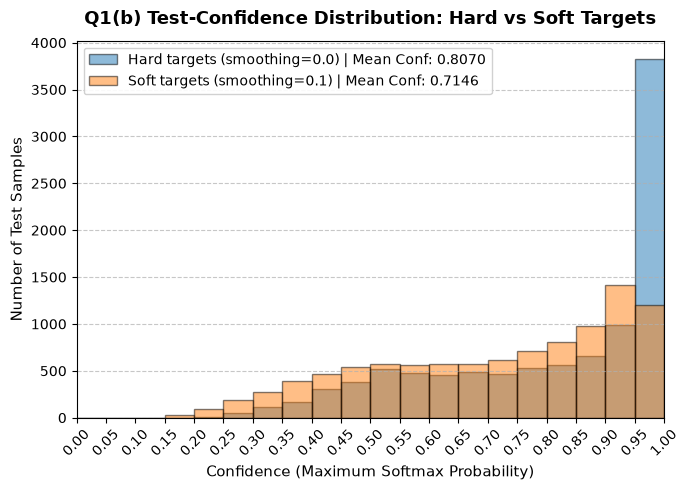

In [7]:
plt.figure(figsize=(7, 5))
bins = np.linspace(0.0, 1.0, 21)

plt.hist(
    confs_hard.numpy(),
    bins=bins,
    alpha=0.5,
    color="#1f77b4",
    edgecolor="black",
    label=f"Hard targets (smoothing=0.0) | Mean Conf: {test_conf_hard:.4f}",
)
plt.hist(
    confs_soft.numpy(),
    bins=bins,
    alpha=0.5,
    color="#ff7f0e",
    edgecolor="black",
    label=f"Soft targets (smoothing=0.1) | Mean Conf: {test_conf_soft:.4f}",
)
plt.title("Q1(b) Test-Confidence Distribution: Hard vs Soft Targets", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Confidence (Maximum Softmax Probability)", fontsize=11)
plt.ylabel("Number of Test Samples", fontsize=11)
plt.xticks(bins, rotation=45)
plt.xlim(0.0, 1.0)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(fontsize=10, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

##### Part (c) : Explain
In three or four sentences, describe the changes in accuracy and confidence. Why do softer targets reduce the pressure toward extreme confidence? Refer to your results, even if accuracy did not improve.


In our FashionMNIST experiment, introducing label smoothing preserved test accuracy with a slight increase from **82.26% to 82.54%**, while significantly reducing the mean test confidence from **0.8070 to 0.7146**. With hard one-hot targets, cross-entropy loss reaches zero only when the winning logit diverges to positive infinity relative to all other logits ($z_{\text{true}} - z_j \to +\infty$), creating persistent gradient pressure that inflates weight magnitudes and drives predictions into the extreme $[0.95, 1.0]$ confidence bin. In contrast, softer targets ($0.91$ for the correct class and $0.01$ for incorrect classes) achieve their theoretical loss minimum at a finite logit difference of $z_{\text{true}}^* - z_j^* = \ln(0.91 / 0.01) \approx 4.51$. Consequently, once this finite separation is attained, gradients diminish, eliminating the incentive for overconfidence and shifting the test confidence distribution into a well-calibrated range.


#### Question 2 : Predict the next letter

Use three previous characters to predict the next one. Start each name with three start tokens and include the final end token. For the name ana, the examples are:

```python
context   target
---       a
--a       n
-an       a
ana       -
```

Use a 27-by-2 embedding table. Concatenate the three embeddings into six numbers, then use a hidden layer of width 32 with ReLU and an output layer of width 27:

```python
embedding = nn.Embedding(27, 2)
network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
)
# context_ids has shape (batch_size, 3)
logits = network(embedding(context_ids).reshape(-1, 6))
```

Both the embedding and network parameters must be included in the optimizer. Use Adam, learning rate 0.001, batch size 256, ordinary cross-entropy, and 20 epochs.

In [8]:
with open("names.csv", encoding="utf-8-sig", newline="") as f:
    names = sorted({
        re.sub(r"[^a-z]", "", row["Name"].lower())
        for row in csv.DictReader(f)
    } - {""})
assert len(names) == 6478

g = torch.Generator().manual_seed(42)
order = torch.randperm(len(names), generator=g).tolist()
train_names = [names[i] for i in order[:5182]]
val_names = [names[i] for i in order[5182:5829]]
test_names = [names[i] for i in order[5829:]]
stoi = {ch: i for i, ch in enumerate("-abcdefghijklmnopqrstuvwxyz")}

##### Part (a) : Train and Evaluate
Plot training and validation loss against epoch. Evaluate both sets at the end of each epoch. Report the selected epoch and test loss, averaged over predicted tokens, including the end token. Use natural logs: the loss is in nats per token.

In [9]:
def build_dataset(name_list, stoi):
    X, Y = [], []
    for name in name_list:
        context = [stoi["-"]] * 3  # Reset 3-char context for every name: [0, 0, 0]
        # Append end token '-' so the final character predicts the end of the name
        for ch in name + "-":
            target_id = stoi[ch]
            X.append(context)
            Y.append(target_id)
            context = context[1:] + [target_id]  # Slide context window
            
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    return TensorDataset(X, Y)

# Build datasets for train, val, and test
train_data_q2 = build_dataset(train_names, stoi)
val_data_q2   = build_dataset(val_names, stoi)
test_data_q2  = build_dataset(test_names, stoi)

print(f"Train examples: {len(train_data_q2)}")
print(f"Val examples:   {len(val_data_q2)}")
print(f"Test examples:  {len(test_data_q2)}")

# Dataloaders
val_loader_q2 = DataLoader(val_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False)
test_loader_q2 = DataLoader(test_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False)

Train examples: 38230
Val examples:   4719
Test examples:  4703


In [10]:
set_seed(42)
embedding = nn.Embedding(27, 2).to(device)
network = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 27),
).to(device)

In [11]:
eval_train_loader_q2 = DataLoader(
    train_data_q2, batch_size=256, shuffle=False, num_workers=0, drop_last=False
)
eval_criterion = nn.CrossEntropyLoss(reduction="sum")
def evaluate_q2(loader):
    embedding.eval()
    network.eval()
    total_loss = 0.0
    total_tokens = 0
    with torch.no_grad():
        for context_ids, targets in loader:
            context_ids, targets = context_ids.to(device), targets.to(device)
            logits = network(embedding(context_ids).reshape(-1, 6))
            loss = eval_criterion(logits, targets)
            total_loss += loss.item()
            total_tokens += targets.size(0)
    return total_loss / total_tokens

optimizer = torch.optim.Adam(
    list(embedding.parameters()) + list(network.parameters()),
    lr=0.001
)

In [12]:
train_loader_q2 = DataLoader(
    train_data_q2,
    batch_size=256,
    shuffle=True,
    num_workers=0,
    drop_last=False,
    generator=torch.Generator().manual_seed(42),
)
train_criterion = nn.CrossEntropyLoss()

# Tracking history and best checkpoint
train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = -1
best_weights = None
print("Training for 20 epochs...")

for epoch in range(1, 21):
    embedding.train()
    network.train()
    for context_ids, targets in train_loader_q2:
        context_ids, targets = context_ids.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = network(embedding(context_ids).reshape(-1, 6))
        loss = train_criterion(logits, targets)
        loss.backward()
        optimizer.step()
        
    # Evaluate both sets at the end of each epoch
    train_loss = evaluate_q2(eval_train_loader_q2)
    val_loss = evaluate_q2(val_loader_q2)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch:2d}/20 | Train Loss: {train_loss:.4f} nats | Val Loss: {val_loss:.4f} nats")
    
    # Save checkpoint if lowest validation loss so far (earlier epoch kept on tie)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_weights = {
            "embedding": copy.deepcopy(embedding.state_dict()),
            "network": copy.deepcopy(network.state_dict()),
        }
        
print(f"\nBest Model Checkpoint: Epoch {best_epoch} with Val Loss = {best_val_loss:.4f} nats")

Training for 20 epochs...
Epoch  1/20 | Train Loss: 2.7494 nats | Val Loss: 2.7612 nats
Epoch  2/20 | Train Loss: 2.6005 nats | Val Loss: 2.6139 nats
Epoch  3/20 | Train Loss: 2.5256 nats | Val Loss: 2.5366 nats
Epoch  4/20 | Train Loss: 2.4756 nats | Val Loss: 2.4825 nats
Epoch  5/20 | Train Loss: 2.4374 nats | Val Loss: 2.4414 nats
Epoch  6/20 | Train Loss: 2.4069 nats | Val Loss: 2.4090 nats
Epoch  7/20 | Train Loss: 2.3855 nats | Val Loss: 2.3855 nats
Epoch  8/20 | Train Loss: 2.3690 nats | Val Loss: 2.3669 nats
Epoch  9/20 | Train Loss: 2.3563 nats | Val Loss: 2.3549 nats
Epoch 10/20 | Train Loss: 2.3451 nats | Val Loss: 2.3421 nats
Epoch 11/20 | Train Loss: 2.3362 nats | Val Loss: 2.3332 nats
Epoch 12/20 | Train Loss: 2.3295 nats | Val Loss: 2.3249 nats
Epoch 13/20 | Train Loss: 2.3216 nats | Val Loss: 2.3194 nats
Epoch 14/20 | Train Loss: 2.3160 nats | Val Loss: 2.3141 nats
Epoch 15/20 | Train Loss: 2.3108 nats | Val Loss: 2.3094 nats
Epoch 16/20 | Train Loss: 2.3057 nats | Val 

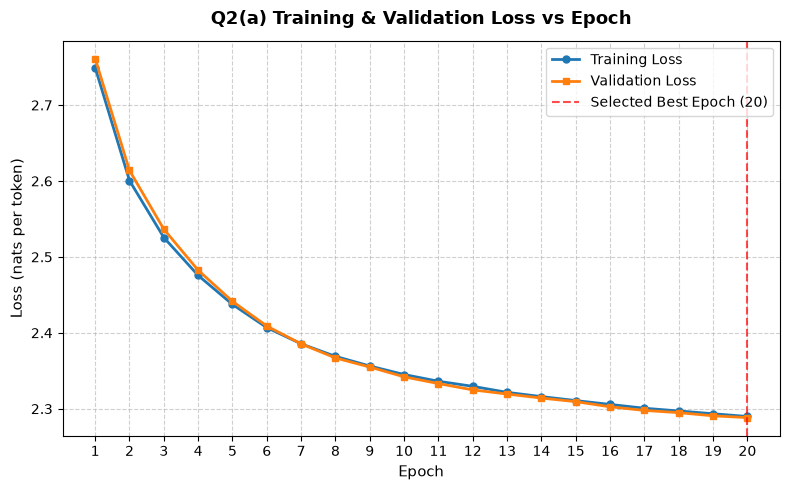

Selected Best Epoch:  Epoch 20
Best Validation Loss: 2.2883 nats per token
Final Test Loss:      2.3216 nats per token


In [13]:
epochs = range(1, 21)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, "o-", color="#1f77b4", label="Training Loss", linewidth=2, markersize=5)
plt.plot(epochs, val_losses, "s-", color="#ff7f0e", label="Validation Loss", linewidth=2, markersize=5)
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Selected Best Epoch ({best_epoch})")

plt.title("Q2(a) Training & Validation Loss vs Epoch", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss (nats per token)", fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10, loc="upper right")
plt.tight_layout()
plt.show()

# Restoring Best Checkpoint before Test Evaluation
embedding.load_state_dict(best_weights["embedding"])
network.load_state_dict(best_weights["network"])

# Evaluating on Test Set
test_loss = evaluate_q2(test_loader_q2)

# Final Results
print("=" * 60)
print(f"Selected Best Epoch:  Epoch {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f} nats per token")
print(f"Final Test Loss:      {test_loss:.4f} nats per token")
print("=" * 60)


##### Part (b): Generate names
Use the selected model to print one greedy name and five sampled names at each temperature: 0.5, 1, and 2. Start every name from the three start tokens. Greedy generation picks the largest logit; sampling uses:

```python
probabilities = torch.softmax(logits / temperature, dim=-1)
next_id = torch.multinomial(probabilities, num_samples=1)
```

After each choice, append the character and slide the context. Stop at the end token or after 20 letters. Mark empty outputs and those that hit the length limit. Reset seed 43 before each temperature’s group of five names. Repeated names are fine.

In [14]:
# Inverse vocabulary mapping
itos = {i: ch for ch, i in stoi.items()}

def generate_name(temperature=None, max_len=20):
    """
    Generates a single name.
    temperature=None -> Greedy decoding
    temperature=float -> Sampling with temperature
    """
    embedding.eval()
    network.eval()
    
    context = [stoi["-"]] * 3
    chars = []
    hit_limit = False
    
    with torch.no_grad():
        for _ in range(max_len):
            context_tensor = torch.tensor([context], dtype=torch.long, device=device)
            logits = network(embedding(context_tensor).reshape(-1, 6))
            
            if temperature is None:
                # Greedy: pick largest logit
                next_id = logits.argmax(dim=-1).item()
            else:
                # Sampling with temperature
                probabilities = torch.softmax(logits / temperature, dim=-1)
                next_id = torch.multinomial(probabilities, num_samples=1).item()
                
            if next_id == stoi["-"]:
                break
                
            chars.append(itos[next_id])
            context = context[1:] + [next_id]
        else:
            hit_limit = True
            
    name = "".join(chars)
    
    # Marking empty outputs and those that hit the 20-letter limit
    flags = []
    if len(name) == 0:
        flags.append("EMPTY")
    if hit_limit:
        flags.append("HIT LENGTH LIMIT (20 letters)")
        
    tag = f"  <-- {', '.join(flags)}" if flags else ""
    return name, tag

In [15]:
# Running generation for temperatures 0.5, 1.0, and 2.0
temperatures = [0.5, 1.0, 2.0]

for temp in temperatures:
    print(f"\n{'='*25} Temperature: {temp} {'='*25}")
    
    # One greedy name
    greedy_name, tag = generate_name(temperature=None)
    print(f"Greedy Name:      '{greedy_name}'{tag}")
    
    # Reset seed 43 before each temperature's group of five names
    set_seed(43)
    
    # Five sampled names
    print("5 Sampled Names:")
    for i in range(1, 6):
        sampled_name, tag = generate_name(temperature=temp)
        print(f"  {i}. '{sampled_name}'{tag}")



========================= Temperature: 0.5 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'ran'
  2. 'ran'
  3. 'bach'
  4. 'sanra'
  5. 'paj'

========================= Temperature: 1.0 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'rer'
  2. 'rainbach'
  3. 'suprame'
  4. 'julinkibaninditah'
  5. 'kosh'

========================= Temperature: 2.0 =========================
Greedy Name:      'sara'
5 Sampled Names:
  1. 'ref'
  2. 'roinbachcvmprach'
  3. 'julitkobaiinumtah'
  4. 'vosh'
  5. 'paf'


##### Part (c): Explain
In three or four sentences, explain why greedy generation repeats the same name from the same start, and describe how temperature affected your samples. All samples should come from the same trained model.

Greedy generation deterministically selects the character with the maximum logit ($\text{argmax}_k z_k$) at every step, so starting from the identical initial context ('---') guarantees an invariant, repeatable trajectory ('sara') with zero stochasticity. At $T = 0.5$, dividing logits by a value less than one sharpens the softmax distribution and concentrates probability mass onto the most frequent transitions, yielding conservative names and noticeable repetition (e.g., 'ran' sampled twice). At $T = 1.0$, the model samples directly from its learned distribution, generating diverse and phonotactically plausible names such as 'rainbach' and 'suprame'. Finally, at $T = 2.0$, the softmax distribution flattens toward uniform entropy, giving low-probability characters a substantial chance of selection and leading to long, chaotic, and atypical letter combinations (such as 'roinbachcvmprach').

#### Question 3 : What does the causal mask do?
This question uses three made-up token vectors and fixed weights. There is no dataset to split and no model to train.

```python
E = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)
W_o = torch.eye(2)
```

In [16]:
E = torch.tensor([[1.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 1.0]])
W_q = torch.eye(2)
W_k = torch.eye(2)
W_v = torch.eye(2)
W_o = torch.eye(2)

#### Part (a): Calculate attention
Write a function that returns the attention matrix and updated token vectors, once with a causal mask and once without it. The code below uses Python’s matrix-multiplication operator:

```python
Q = E @ W_q
K = E @ W_k
V = E @ W_v
scores = (Q @ K.transpose(-2, -1)) / (2 ** 0.5)

# For the causal run, mask future scores here, before softmax.
A = torch.softmax(scores, dim=-1)
updated = E + (A @ V) @ W_o
```

For query row i, set scores in columns j greater than i to negative infinity in the causal run. Keep the diagonal. Softmax runs across each row, over source tokens. Both returned arrays have three rows; A has three columns and updated has two.

Print A and updated for both runs. Check that each attention row sums to 1 and that masked future weights are zero.

In [17]:
def calculate_attention(E, W_q, W_k, W_v, W_o, causal=False):
    """
    Computes attention matrix A (3x3) and updated token vectors (3x2).
    """
    Q = E @ W_q
    K = E @ W_k
    V = E @ W_v
    
    scores = (Q @ K.transpose(-2, -1)) / (2 ** 0.5)
    
    if causal:
        # Clone scores to avoid in-place modification of any shared tensors
        scores = scores.clone()
        # For query row i, set scores in columns j > i to -inf (keep diagonal and past)
        mask = torch.triu(torch.ones_like(scores, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        
    A = torch.softmax(scores, dim=-1)
    updated = E + (A @ V) @ W_o
    return A, updated

In [18]:
# Run without causal mask
A_unmasked, updated_unmasked = calculate_attention(E, W_q, W_k, W_v, W_o, causal=False)

# Run with causal mask
A_causal, updated_causal = calculate_attention(E, W_q, W_k, W_v, W_o, causal=True)

# Results
print("=" * 60)
print("1. UNMASKED (BIDIRECTIONAL) ATTENTION:")
print("Attention Matrix A (3x3):")
print(A_unmasked)
print("\nUpdated Token Vectors (3x2):")
print(updated_unmasked)
print("\n" + "=" * 60)
print("2. CAUSAL (MASKED) ATTENTION:")
print("Attention Matrix A (3x3):")
print(A_causal)
print("\nUpdated Token Vectors (3x2):")
print(updated_causal)
print("=" * 60)

# Verification checks

# Check that each attention row sums to 1
assert torch.allclose(A_unmasked.sum(dim=-1), torch.ones(3)), "Unmasked rows must sum to 1"
assert torch.allclose(A_causal.sum(dim=-1), torch.ones(3)), "Causal rows must sum to 1"

# Check that masked future weights are zero (j > i)
mask_future = torch.triu(torch.ones_like(A_causal, dtype=torch.bool), diagonal=1)
assert torch.all(A_causal[mask_future] == 0.0), "Future attention weights must be exactly 0.0"
print("\nAll verification checks passed:")
print("- Each attention row sums to 1.0 (Unmasked row sums:", A_unmasked.sum(dim=-1).tolist(), ")")
print("- Each attention row sums to 1.0 (Causal row sums:", A_causal.sum(dim=-1).tolist(), ")")
print("- Masked future weights in causal matrix are strictly zero:", A_causal[mask_future].tolist())


1. UNMASKED (BIDIRECTIONAL) ATTENTION:
Attention Matrix A (3x3):
tensor([[0.4011, 0.1978, 0.4011],
        [0.1978, 0.4011, 0.4011],
        [0.2483, 0.2483, 0.5035]])

Updated Token Vectors (3x2):
tensor([[1.8022, 0.5989],
        [0.5989, 1.8022],
        [1.7517, 1.7517]])

2. CAUSAL (MASKED) ATTENTION:
Attention Matrix A (3x3):
tensor([[1.0000, 0.0000, 0.0000],
        [0.3302, 0.6698, 0.0000],
        [0.2483, 0.2483, 0.5035]])

Updated Token Vectors (3x2):
tensor([[2.0000, 0.0000],
        [0.3302, 1.6698],
        [1.7517, 1.7517]])

All verification checks passed:
- Each attention row sums to 1.0 (Unmasked row sums: [1.0, 1.0, 1.0] )
- Each attention row sums to 1.0 (Causal row sums: [1.0, 1.0, 1.0] )
- Masked future weights in causal matrix are strictly zero: [0.0, 0.0, 0.0]


##### Part (b) Show the Mask
Plot the two 3-by-3 attention matrices side by side, with the same colour scale from 0 to 1. Label rows as query positions and columns as source positions, numbered 0, 1, and 2.

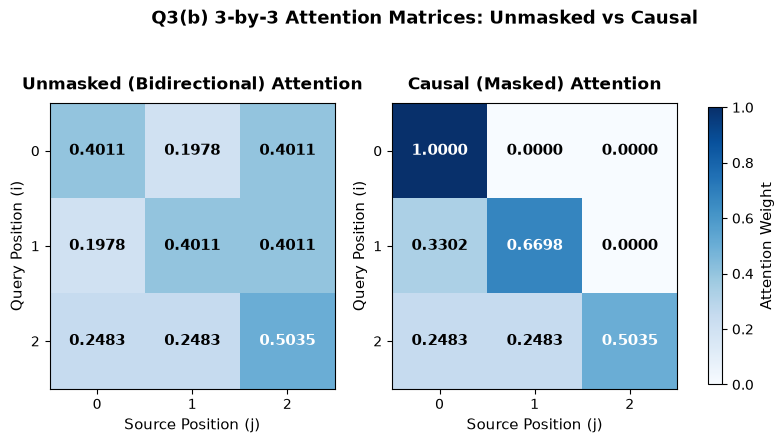

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

matrices = [
    (A_unmasked.numpy(), "Unmasked (Bidirectional) Attention"),
    (A_causal.numpy(), "Causal (Masked) Attention"),
]

for ax, (mat, title) in zip(axes, matrices):
    im = ax.imshow(mat, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Source Position (j)", fontsize=11)
    ax.set_ylabel("Query Position (i)", fontsize=11)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    
    # Annotate numeric values inside each cell
    for i in range(3):
        for j in range(3):
            val = mat[i, j]
            # Use white text on dark cells and black text on light cells for contrast
            text_color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center", color=text_color, fontsize=11, fontweight="bold")

# Add shared colorbar across both subplots
cbar = fig.colorbar(im, ax=axes, shrink=0.8, pad=0.04)
cbar.set_label("Attention Weight", fontsize=11)
cbar.set_ticks(np.linspace(0.0, 1.0, 6))

plt.suptitle("Q3(b) 3-by-3 Attention Matrices: Unmasked vs Causal", fontsize=13, fontweight="bold", y=1.02)
plt.show()


##### Part (c): Change a future token
Replace the last input vector and repeat both calculations:

```python
changed_E = E.clone()
changed_E[2] = torch.tensor([4.0, 4.0])
```

For each mask setting, report the largest absolute change in the first two updated rows. Then explain in three or four sentences why the causal version keeps those rows unchanged and how this prevents a next-token predictor from seeing future inputs. Tiny floating-point differences are acceptable.

In [20]:
# Replace the last input vector (future token)
changed_E = E.clone()
changed_E[2] = torch.tensor([4.0, 4.0])

# Re-compute calculations with changed_E
A_unmasked_changed, updated_unmasked_changed = calculate_attention(
    changed_E, W_q, W_k, W_v, W_o, causal=False
)
A_causal_changed, updated_causal_changed = calculate_attention(
    changed_E, W_q, W_k, W_v, W_o, causal=True
)

# Compute absolute change in the first two updated rows (rows 0 and 1)
diff_unmasked = (updated_unmasked_changed[:2] - updated_unmasked[:2]).abs()
max_diff_unmasked = diff_unmasked.max().item()

diff_causal = (updated_causal_changed[:2] - updated_causal[:2]).abs()
max_diff_causal = diff_causal.max().item()

print("=" * 65)
print("UPDATED TOKEN VECTORS (FIRST TWO ROWS):")
print("\nOriginal Unmasked (rows 0 & 1):")
print(updated_unmasked[:2])
print("Changed Unmasked (rows 0 & 1):")
print(updated_unmasked_changed[:2])
print(f"--> Largest Absolute Change (Unmasked): {max_diff_unmasked:.6f}")

print("\nOriginal Causal (rows 0 & 1):")
print(updated_causal[:2])
print("Changed Causal (rows 0 & 1):")
print(updated_causal_changed[:2])
print(f"--> Largest Absolute Change (Causal):   {max_diff_causal:.6f}")
print("=" * 65)


UPDATED TOKEN VECTORS (FIRST TWO ROWS):

Original Unmasked (rows 0 & 1):
tensor([[1.8022, 0.5989],
        [0.5989, 1.8022]])
Changed Unmasked (rows 0 & 1):
tensor([[4.4944, 3.4429],
        [3.4429, 4.4944]])
--> Largest Absolute Change (Unmasked): 2.844011

Original Causal (rows 0 & 1):
tensor([[2.0000, 0.0000],
        [0.3302, 1.6698]])
Changed Causal (rows 0 & 1):
tensor([[2.0000, 0.0000],
        [0.3302, 1.6698]])
--> Largest Absolute Change (Causal):   0.000000


In the causal attention setting, query rows 0 and 1 have their attention scores to token 2 masked to $-\infty$, resulting in exactly zero attention weight ($A_{0,2} = 0$, $A_{1,2} = 0$) assigned to the future token. Because token 2 contributes nothing to the value aggregation of the earlier tokens, altering its embedding from $[1.0, 1.0]$ to $[4.0, 4.0]$ produces a maximum absolute change of exactly 0.0 in the first two updated rows. In contrast, under unmasked attention, the first two tokens attend substantially to token 2, causing their updated representations to change drastically by a maximum of 2.8440. This strict causal isolation prevents information from future positions from leaking backward, ensuring that an autoregressive model predicts the next token based exclusively on past context without "cheating" by peeking ahead.

#### Question 4 : Image patches and positions
Use the same FashionMNIST sets as Q1. Cut each image into 49 non-overlapping 4-by-4 patches, ordered left to right, then top to bottom. Flatten each patch in row-major order to 16 numbers.

Use a shared linear layer to turn each patch into 32 numbers. Prepend a learned CLS token and add a learned position table for the 50 rows. Use one Transformer block, with two attention heads of width 16:

```python
patch projection: 16 inputs -> 32 outputs
position table:   50 rows, each of width 32
MLP:              32 -> 64 -> 32, with GELU
```

Let X contain the patch embeddings and CLS row, after the optional position addition. Its shape is batch size by 50 by 32. Row 0 is CLS. The block has two residual updates, and each LayerNorm operates on width 32:

```python
normalized = norm1(X)
message, _ = attention(normalized, normalized, normalized)
U = X + message
Z = U + mlp(norm2(U))
logits = classifier(final_norm(Z[:, 0, :]))
```

The attention and final classifier may use these PyTorch layers:

```python
attention = nn.MultiheadAttention(
    embed_dim=32, num_heads=2, dropout=0.0, batch_first=True
)
classifier = nn.Linear(32, 10)
```

Use no causal mask: the whole image is available. Use AdamW, learning rate 0.001, weight decay 0.01 on all parameters, batch size 128, and 10 epochs.

In [ ]:
def extract_patches(images):
    """
    Cuts images of shape (B, 1, 28, 28) into 49 non-overlapping 4x4 patches.
    Flattens each patch in row-major order to 16 numbers.
    Returns tensor of shape (B, 49, 16).
    """
    # unfold extracts patches of size 4x4 with stride 4: shape (B, 16, 49)
    patches = F.unfold(images, kernel_size=4, stride=4)
    # Transpose so sequence dimension is dim 1: shape (B, 49, 16)
    patches = patches.transpose(1, 2)
    return patches
    
# Quick verification on a dummy batch
sample_images = torch.randn(4, 1, 28, 28)
sample_patches = extract_patches(sample_images)
print("Sanity check extract_patches output shape:", sample_patches.shape)
assert sample_patches.shape == (4, 49, 16), "Shape must be (B, 49, 16)"

Sanity check extract_patches output shape: torch.Size([4, 49, 16])


##### Part (a): Train and compare
Train two variants from identical shared initial weights: one adds position vectors, and one skips that addition. Each selects its checkpoint using the original validation set.

Report the selected epoch and original test accuracy for each model. Then report test accuracy after shuffling whole patches. Use the original clothing labels, and evaluate without retraining.

To create the shuffled test set, use a fresh NumPy generator with seed 44. Generate one permutation per image, in official test order:

```python
rng = np.random.default_rng(44)
# Repeat once for each test image:
patch_order = rng.permutation(49)
```

Move whole patches according to that order. Leave pixels within each patch and the CLS token unchanged. Keep position vectors attached to the destination slots. Reuse exactly the same shuffled images for both models.

In [23]:
class VisionTransformer(nn.Module):
    def __init__(self, use_positions=True):
        super().__init__()
        self.use_positions = use_positions
        
        # Patch projection: 16 inputs -> 32 outputs
        self.patch_proj = nn.Linear(16, 32)
        
        # Learned CLS token: (1, 1, 32) initialized with mean 0, std 0.02
        self.cls_token = nn.Parameter(torch.empty(1, 1, 32))
        nn.init.normal_(self.cls_token, mean=0.0, std=0.02)
        
        # Learned position table: 50 rows, each of width 32 (mean 0, std 0.02)
        self.pos_table = nn.Parameter(torch.empty(1, 50, 32))
        nn.init.normal_(self.pos_table, mean=0.0, std=0.02)
        
        # Transformer Block components
        self.norm1 = nn.LayerNorm(32)
        self.attention = nn.MultiheadAttention(
            embed_dim=32, num_heads=2, dropout=0.0, batch_first=True
        )
        
        self.norm2 = nn.LayerNorm(32)
        self.mlp = nn.Sequential(
            nn.Linear(32, 64),
            nn.GELU(),
            nn.Linear(64, 32),
        )
        
        # Final norm and classifier
        self.final_norm = nn.LayerNorm(32)
        self.classifier = nn.Linear(32, 10)
        
    def forward(self, images):
        # images: (B, 1, 28, 28)
        # Extract 49 patches: (B, 49, 16)
        patches = extract_patches(images)
        
        # Project patches to width 32: (B, 49, 32)
        patch_embeds = self.patch_proj(patches)
        
        # Prepend learned CLS token: (B, 1, 32) -> (B, 50, 32)
        B = images.size(0)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        X = torch.cat([cls_tokens, patch_embeds], dim=1)
        
        # Optional position addition
        if self.use_positions:
            X = X + self.pos_table
            
        # Transformer Block with residual updates
        normalized = self.norm1(X)
        message, _ = self.attention(normalized, normalized, normalized)
        U = X + message
        Z = U + self.mlp(self.norm2(U))
        
        # Classify from CLS token (row 0)
        cls_out = Z[:, 0, :]
        logits = self.classifier(self.final_norm(cls_out))
        return logits

# Quick sanity check on forward pass
set_seed(42)
test_model_pos = VisionTransformer(use_positions=True).to(device)
test_model_nopos = VisionTransformer(use_positions=False).to(device)

with torch.no_grad():
    dummy_img = torch.randn(2, 1, 28, 28, device=device)
    out_pos = test_model_pos(dummy_img)
    out_nopos = test_model_nopos(dummy_img)
    print("Sanity check forward pass (with pos):   ", out_pos.shape)
    print("Sanity check forward pass (without pos):", out_nopos.shape)
    assert out_pos.shape == (2, 10) and out_nopos.shape == (2, 10)


Sanity check forward pass (with pos):    torch.Size([2, 10])
Sanity check forward pass (without pos): torch.Size([2, 10])


In [24]:
# Evaluation function for ViT
eval_criterion_vit = nn.CrossEntropyLoss(reduction="sum")

def evaluate_vit(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = eval_criterion_vit(logits, targets)
            total_loss += loss.item()
            preds = logits.argmax(dim=-1)
            total_correct += (preds == targets).sum().item()
            total_samples += targets.size(0)
    return total_loss / total_samples, total_correct / total_samples

In [25]:
# Training function
def train_vit_model(model, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    train_criterion = nn.CrossEntropyLoss()
    
    # Fresh training loader with seed 42
    train_loader = DataLoader(
        train_data,
        batch_size=128,
        shuffle=True,
        num_workers=0,
        drop_last=False,
        generator=torch.Generator().manual_seed(42),
    )
    
    best_val_loss = float("inf")
    best_epoch = -1
    best_weights = None
    
    for epoch in range(1, 11):
        model.train()
        train_loss_sum = 0.0
        train_samples = 0
        
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = train_criterion(logits, targets)
            loss.backward()
            optimizer.step()
            
            train_loss_sum += loss.item() * targets.size(0)
            train_samples += targets.size(0)
            
        train_loss = train_loss_sum / train_samples
        val_loss, val_acc = evaluate_vit(model, val_loader)
        print(f"Epoch {epoch:2d}/10 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        
        # Save lowest validation loss checkpoint (earlier epoch in ties)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            
    print(f"\nSelected Best Epoch: Epoch {best_epoch} (Val Loss = {best_val_loss:.4f})")
    
    # Restore best weights before test evaluation
    model.load_state_dict(best_weights)
    test_loss, test_acc = evaluate_vit(model, test_loader)
    print(f"Original Test Accuracy: {test_acc*100:.2f}% (Loss = {test_loss:.4f})")
    
    return best_epoch, test_acc

In [26]:
# Build Model 1: With Positions
set_seed(42)
model_pos = VisionTransformer(use_positions=True).to(device)

# Build Model 2: Without Positions (copy identical initial parameters)
model_nopos = VisionTransformer(use_positions=False).to(device)
model_nopos.load_state_dict(model_pos.state_dict())

# Train both models
best_epoch_pos, test_acc_pos = train_vit_model(
    model_pos, "Model 1: With Positions (use_positions=True)"
)

best_epoch_nopos, test_acc_nopos = train_vit_model(
    model_nopos, "Model 2: Without Positions (use_positions=False)"
)



==================== Model 1: With Positions (use_positions=True) ====================
Epoch  1/10 | Train Loss: 1.8672 | Val Loss: 1.4726 | Val Acc: 39.00%
Epoch  2/10 | Train Loss: 1.2636 | Val Loss: 1.1320 | Val Acc: 57.80%
Epoch  3/10 | Train Loss: 1.0159 | Val Loss: 0.9390 | Val Acc: 64.00%
Epoch  4/10 | Train Loss: 0.8656 | Val Loss: 0.8102 | Val Acc: 69.60%
Epoch  5/10 | Train Loss: 0.7872 | Val Loss: 0.7923 | Val Acc: 70.30%
Epoch  6/10 | Train Loss: 0.7693 | Val Loss: 0.7858 | Val Acc: 69.80%
Epoch  7/10 | Train Loss: 0.7268 | Val Loss: 0.7255 | Val Acc: 71.30%
Epoch  8/10 | Train Loss: 0.6759 | Val Loss: 0.7239 | Val Acc: 72.50%
Epoch  9/10 | Train Loss: 0.6687 | Val Loss: 0.7051 | Val Acc: 72.40%
Epoch 10/10 | Train Loss: 0.6447 | Val Loss: 0.6295 | Val Acc: 75.90%

Selected Best Epoch: Epoch 10 (Val Loss = 0.6295)
Original Test Accuracy: 76.73% (Loss = 0.6351)

==================== Model 2: Without Positions (use_positions=False) ====================
Epoch  1/10 | Train Lo

In [27]:
# Collect all original test images and labels
test_images = []
test_targets = []
for img, target in test_data:
    test_images.append(img)
    test_targets.append(target)
test_images = torch.stack(test_images)       # (10000, 1, 28, 28)
test_targets = torch.tensor(test_targets, dtype=torch.long)  # (10000,)

# Extract 49 patches (each 4x4 = 16 pixels) for all test images: shape (10000, 16, 49)
all_test_patches = F.unfold(test_images, kernel_size=4, stride=4)

# Create fresh NumPy generator with seed 44 and shuffle patches per image
rng = np.random.default_rng(44)
shuffled_patches = torch.empty_like(all_test_patches)

for i in range(len(test_data)):
    patch_order = rng.permutation(49)
    # Permute the 49 patch columns for image i
    shuffled_patches[i] = all_test_patches[i, :, patch_order]

# Fold shuffled patches back into image format (10000, 1, 28, 28)
shuffled_test_images = F.fold(
    shuffled_patches, output_size=(28, 28), kernel_size=4, stride=4
)

# Create DataLoader for the shuffled test set
shuffled_test_data = TensorDataset(shuffled_test_images, test_targets)
shuffled_test_loader = DataLoader(
    shuffled_test_data, batch_size=128, shuffle=False, num_workers=0, drop_last=False
)

# Evaluate both models on the shuffled test set without retraining
shuffled_loss_pos, shuffled_acc_pos = evaluate_vit(model_pos, shuffled_test_loader)
shuffled_loss_nopos, shuffled_acc_nopos = evaluate_vit(model_nopos, shuffled_test_loader)

# Print Comparative Summary for Q4(a)
print("=" * 80)
print(f"{'Model Variant':<28} | {'Selected Epoch':<15} | {'Original Test Acc':<18} | {'Shuffled Test Acc':<18}")
print("-" * 80)
print(f"{'With Positions (True)':<28} | Epoch {best_epoch_pos:<9} | {test_acc_pos*100:.2f}% ({test_acc_pos:.4f})   | {shuffled_acc_pos*100:.2f}% ({shuffled_acc_pos:.4f})")
print(f"{'Without Positions (False)':<28} | Epoch {best_epoch_nopos:<9} | {test_acc_nopos*100:.2f}% ({test_acc_nopos:.4f})   | {shuffled_acc_nopos*100:.2f}% ({shuffled_acc_nopos:.4f})")
print("=" * 80)


Model Variant                | Selected Epoch  | Original Test Acc  | Shuffled Test Acc 
--------------------------------------------------------------------------------
With Positions (True)        | Epoch 10        | 76.73% (0.7673)   | 17.98% (0.1798)
Without Positions (False)    | Epoch 9         | 60.93% (0.6093)   | 60.93% (0.6093)


##### Part (b): Show the inputs
Show the first two original test images next to their patch-shuffled versions, with the true clothing labels.

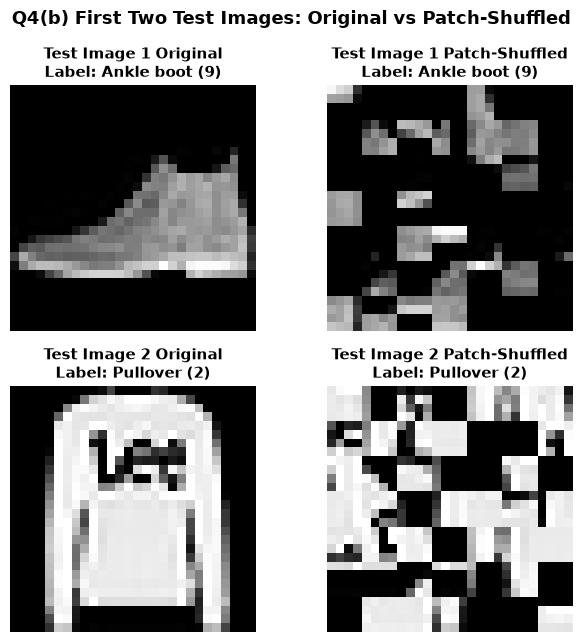

In [28]:
# FashionMNIST class names
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 2, figsize=(6.5, 6.5))

for i in range(2):
    orig_img = test_images[i].squeeze(0).numpy()
    shuff_img = shuffled_test_images[i].squeeze(0).numpy()
    label_id = test_targets[i].item()
    label_name = class_names[label_id]
    
    # Original image
    axes[i, 0].imshow(orig_img, cmap="gray")
    axes[i, 0].set_title(f"Test Image {i+1} Original\nLabel: {label_name} ({label_id})", fontsize=11, fontweight="bold")
    axes[i, 0].axis("off")
    
    # Shuffled image
    axes[i, 1].imshow(shuff_img, cmap="gray")
    axes[i, 1].set_title(f"Test Image {i+1} Patch-Shuffled\nLabel: {label_name} ({label_id})", fontsize=11, fontweight="bold")
    axes[i, 1].axis("off")

plt.suptitle("Q4(b) First Two Test Images: Original vs Patch-Shuffled", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()


##### Part (c): Explain
In three or four sentences, explain why the model without positions should preserve its predictions when whole patches are rearranged, apart from numerical rounding. Why can the model with positions respond differently? A pixel shift or rotation changes patch contents, so this argument does not apply to those operations.

Because self-attention operates via pairwise dot products and commutative weighted summation, the model without position embeddings treats the input patches as an unordered set, making the updated [CLS] representation mathematically invariant to any permutation of the sequence. Consequently, rearranging intact patches merely reorders the terms in the attention aggregation, preserving the exact same logits and predictions up to numerical floating-point rounding (60.93% \to 60.93%). In contrast, the model with positions adds fixed coordinate vectors to destination slots, so shuffling patches pairs visual patterns with incorrect spatial coordinates (e.g., mapping sole features to collar slots), which corrupts the learned geometric cues and severely degrades classification accuracy (76.73% \to 17.98%). Crucially, this permutation invariance holds only because the internal contents of each patch are left untouched, whereas pixel shifts or rotations alter the pixel values within patches and would change the projected patch representations themselves.